## Biophysical branching model

Lingchong You

In this notebook, we leverage Jax in order to perform GPU accelerated simulation of branching model by simulating nutrient diffusion and density-dependent diffusion of cell dispersal.


Need to do:
- fix nutrient boundary conditions
- check surfactant after certain time point. why dissapear?
- reduce time to run, maybe not possible with 9 point 3 species (maybe use only laplacian or diffusion)
- 1 problem with each 
    - hyperswarmer forms branches too soon
    - wildtype forms branches too late
    - cheater forms a square

In [1]:
#%reset -f
# Import numerical jax dependencies
import jax
from jax import numpy as jnp
from jax import vmap
from jax import jit

# For readability. 
from collections import namedtuple

# Import plotting dependencies
import matplotlib.pyplot as plt
from jax_tqdm import scan_tqdm
from IPython.display import clear_output
import time

import os
import numpy as np

/hpc/group/youlab/rah94/miniconda3/envs/jax_patterns/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modified by KS ->  Addition of more species(Cheater and Hyperswarmer) to the grid. Cheater does not have the producer fraction, and the hyperswarmer has a higher coefficient of production of surfactant \(a_{s2})

### Model description

(This model was partially based on a model formulation initially developed by Nan Luo.)

We have four fields representing nutrient ($N$), producer ($P$), grower ($G$), and surfactant ($S$). The reaction-diffusion equations for each of these fields can be written as follows:

#### 1. **Nutrient ($N$)**

$$


\frac{\partial N}{\partial t}
=
- b_N f_G \left(a_P P + a_G G\right)
- b_N f_c \left(a_G G_c\right)
- b_N f_{HS}\left(a_P P_{HS} + a_G G_{HS}\right)
+ D_N \nabla^2 N

$$

where:

$$
f_G = \frac{N}{N + K_N} \left(1 - \frac{C}{C_{\text{max}}}\right), \quad C = P + G

$$

$$

f_{C}=
\frac{N}{N+k_N}
\left(1-\frac{C_C}{(C_C)_{\max}}\right) ,  \quad C_{C} = G_{HS}

$$

$$

f_{HS}
=
\frac{N}{N+k_N}
\left(1-\frac{C_{HS}}{(C_{HS})_{\max}}\right), \quad C_{HS} = P_{HS} + G_{HS}

$$



#### 2. **Producer ($P$)**

$$
\frac{\partial P}{\partial t} = a_P f_G P - k_G P + k_P f_T G + \nabla \cdot (D_P \nabla P)
$$

where:

$$
f_T = \frac{K_T^n}{N^n + K_T^n}, \quad D_P = k_D (1 + \text{noise}) S
$$

#### 3. **Grower ($G$)**

$$
\frac{\partial G}{\partial t} = a_G f_G G + k_G P - k_P f_T G + \nabla \cdot (D_G \nabla G)
$$

where:

$$
D_G = k_D (1 + \text{noise}) S
$$


#### 4. **Grower Cheater ($G_C$)**

$$
\frac{\partial G_c}{\partial t}
=
\alpha_c f_c G_c
+ \nabla \!\left(D_{G_c}\,\nabla G_c\right)
$$

where:

$$
D_{G_c} = k_D (1 + \text{noise}) S
$$



#### 5. **Producer Hyperswarmer  ($P_{HS}$)**

$$

\frac{\partial P_{HS}}{\partial t}
=
a_P f_{HS} G_{HS}
- k_{G} P_{HS}
+ k_P f_T G_{HS}
+ \nabla \!\left(D_n \,\nabla G_{HS}\right)

$$


#### 6. **Grower Hyperswarmer  ($G_{HS}$)**

$$
\frac{\partial G_{HS}}{\partial t}
=
\alpha_c f_{HS} G_{HS}
- k_P f_T G_{HS}
+ k_{G} P_{HS}
+ \nabla \!\left(D_{G_{HS}} \,\nabla G_{HS}\right)
$$

where:

$$
D_{G_{HS}} = k_D (1 + \text{noise}) S
$$



#### 7. **Surfactant ($S$)**

$$
\frac{\partial S}{\partial t}
=
\alpha_S P\,f
+ \alpha_{S2} P_{HS}\,f_{HS2}
- b_S S
+ D_S \nabla^2 S
$$

where:

$$
f = f_{QS} f_E f_P,f_{HS2} = f_{QS2} f_E f_P

$$

$$
\quad f_{QS} = \frac{C^d}{C^d + K_C^d},\quad f_{QS2} = \frac{C_{HS2}^d}{C_{HS2}^d + K_C^d}, \quad f_E = \frac{K_E^a}{N^a + K_E^a}, \quad f_P = \frac{N^b}{N^b + K_P^b}
$$

### Summary of Dynamics

- **Nutrient ($N$)**: Decreases due to consumption by both producers and growers.
- **Producer ($P$)**: Growth depends on available nutrients, and producers can also decay or get converted into growers.
- **Grower ($G$)**: Grows using nutrients and can be produced from producers.
- **Surfactant ($S$)**: Produced by the producer and decays naturally. The surfactant affects the diffusivity of both the producer and grower fields.

These equations describe a reaction-diffusion system that involves:
- **Diffusion**: Represented by terms involving $\nabla^2$ or $\nabla \cdot (D \nabla U)$.
- **Reaction Terms**: Represented by production, consumption, and conversion interactions involving multiple species and parameters.


### Mathematical Description of numerical operations.

This section provides a mathematical description of the functions implemented in the code, focusing on initializing fields and the numerical operators used for spatial diffusion.

#### 1. **Field Initialization**
The function `initialize_fields(nx, ny, Lx, Ly, N0, C0, R0)` initializes the fields \(N\), \(P\), \(G\), and \(S\) over a 2D grid with dimensions \(nx 	times ny\). The physical domain has sizes \(L_x\) and \(L_y\).

- **Nutrient Field (\(N\))**: Initialized uniformly across the domain with concentration \(N_0\).
  
  $$
  N(x, y) = N_0, \quad \forall (x, y) \in [0, L_x] \times [0, L_y]
  $$

- **Producer Field (\(P\))**: Initialized as zero throughout the domain.

  $$
  P(x, y) = 0, \quad \forall (x, y) \in [0, L_x] \times [0, L_y]
  $$

- **Grower Field (\(G\))**: Initialized with a Gaussian distribution centered in the domain, with an initial concentration \(C_0\) and standard deviation corresponding to \(R_0\).

  $$
  G(x, y) = C_0 \exp\left(-\frac{(x - L_x/2)^2 + (y - L_y/2)^2}{R_0^2}\right)
  $$

- **Surfactant Field (\(S\))**: Initialized as zero throughout the domain.

  $$
  S(x, y) = 0, \quad \forall (x, y) \in [0, L_x] \times [0, L_y]
  $$

#### 2. **Laplacian Operator**
The function `laplacian(U, dx, dy)` computes the Laplacian of a 2D field \(U\) using central difference approximations. The Laplacian is used to represent the diffusion process and is defined as:

$$
\nabla^2 U = \frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2}
$$

Using finite differences, the Laplacian is approximated as:

$$
\nabla^2 U_{i,j} \approx \frac{U_{i+1,j} - 2U_{i,j} + U_{i-1,j}}{dx^2} + \frac{U_{i,j+1} - 2U_{i,j} + U_{i,j-1}}{dy^2}
$$

#### 3. **Diffusion Operator with Variable Diffusivity**
The function `diffusion_operator(U, D, dx)` computes the diffusion term \(\nabla \cdot (D \nabla U)\) for a 2D field \(U\) with a spatially variable diffusivity \(D\). Neumann boundary conditions (zero-flux) are implemented by padding the field values at the boundaries.

The diffusion operator is given by:

$$
\nabla \cdot (D \nabla U) = D \nabla^2 U + \nabla D \cdot \nabla U
$$

Where:
- **Term 1**: \(D \nabla^2 U\) represents the standard diffusion with diffusivity \(D\).
- **Term 2**: \(\nabla D \cdot \nabla U\) accounts for the spatial variation in diffusivity.

The finite difference approximations for these terms are:

- **Gradient of \(U\)**:

  $$
  \frac{\partial U}{\partial x} \approx \frac{U_{i+1, j} - U_{i-1, j}}{2 dx}, \quad \frac{\partial U}{\partial y} \approx \frac{U_{i, j+1} - U_{i, j-1}}{2 dx}
  $$

- **Gradient of \(D\)**:

  $$
  \frac{\partial D}{\partial x} \approx \frac{D_{i+1, j} - D_{i-1, j}}{2 dx}, \quad \frac{\partial D}{\partial y} \approx \frac{D_{i, j+1} - D_{i, j-1}}{2 dx}
  $$

- **Laplacian of \(U\)**:

  $$
  \nabla^2 U_{i,j} \approx \frac{U_{i+1,j} - 2U_{i,j} + U_{i-1,j}}{dx^2} + \frac{U_{i,j+1} - 2U_{i,j} + U_{i,j-1}}{dx^2}
  $$

The resulting diffusion term is computed as:

$$
\nabla \cdot (D \nabla U) = D \nabla^2 U + \frac{\partial D}{\partial x} \cdot \frac{\partial U}{\partial x} + \frac{\partial D}{\partial y} \cdot \frac{\partial U}{\partial y}
$$

### Summary
- **Field Initialization**: The fields \(N\), \(P\), \(G\), and \(S\) are initialized with specified initial conditions over a 2D domain.
- **Laplacian Operator**: Approximates the second-order spatial derivatives for diffusion.
- **Diffusion with Variable Diffusivity**: Computes the spatial diffusion of a field considering both constant and variable diffusivities, using finite difference methods to approximate gradients and Laplacians.

These operators are used to model the evolution of nutrient, producer, grower, and surfactant fields in a 2D spatial domain with diffusion and reaction dynamics.


In [ ]:
# ==== Module-level grid & simulation constants ====
# Must be defined BEFORE the PDE functions so K2 is in scope when JIT traces.

# Grid
nx, ny  = 600, 600
Lx, Ly  = 180.0, 180.0
dx = Lx / nx
dy = Ly / ny

# Time stepping
dt = 1e-3
nt = 20000
frames = 5
R0 = 1.0          # Gaussian seed radius

# Noise amplitude
epsilon = 0.2

Parameters = [
    8,    #  DN = 1-20 (good results) 
    0.579,    # DS = 5.79
    2e3,    # kP * Cmax, kD = 2.58e3
    22,    # bN * Cmax/KN; bN = 15
    24.24,    # aG= 24.24
    8.67,    # aP/aP; aP = 8.67 
    75.36,    # kG = 75.36
    16.98,    # kP = 16.98

    1,   # KN (fixed. scaling basis for concentrations)

    10,    # KT/KN; KT = 6.45

    1,    #  aS = 1.0 (fixed. basis for time)

    0, #aS1 (cheater) keeping this at 0 forms most realistic as of now. any >0 forms square, may not be biologically true

    2,   # aS2 = 2.0....(hyperswarmer )

    5,    #  bS = 170.52
    9,    # KE/KN; KE = 6.08
    6,    # KC/KN; KC = 4.55

    10,    #Cmax/Cmax; Cmax= 10  (fixed. scaling basis for cell density and surfactant)

    2,    # n_param
    2.205,    # d_param
    1.69,    # a_param
    1.84,    # b_param
    3.21,    # KP/KN; KP_p = 2.06
    50,    # N0/KN; N0 = 31.5
    0.2     # C0/Cmax; C0 = 1.59
]

DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, aS1, as2, bS, KE, KC, Cmax, n, d, a, b, KP, N0, C0 = Parameters




# ------------------------------------------------------------------
# Pseudospectral wavenumber grid for isotropic Laplacian of N and S.
# K2[i,j] = kx[i]^2 + ky[j]^2  in (rad / length)^2.
# Assumes periodic domain [0, Lx] x [0, Ly].
# ------------------------------------------------------------------
_kx = jnp.fft.fftfreq(nx, d=1.0 / nx) * (2.0 * jnp.pi / Lx)
_ky = jnp.fft.fftfreq(ny, d=1.0 / ny) * (2.0 * jnp.pi / Ly)
_KX, _KY = jnp.meshgrid(_kx, _ky, indexing='ij')
K2 = _KX**2 + _KY**2   # shape (nx, ny)

print(f"Grid: {nx}x{ny},  dx={dx:.4f},  dt={dt},  K2 shape: {K2.shape}")

Grid: 600x600,  dx=0.3000,  dt=0.001,  K2 shape: (600, 600)


In [3]:
def initialize_fields(nx, ny, Lx, Ly, N0, C0, R0 , locs_wt = None, locs_cheater= None, locs_hypsw=None):
    """
    Initializes the fields N, P, G, S.
    
    Parameters:
    - nx, ny: Grid dimensions.
    - Lx, Ly: Physical domain sizes.
    - N0: Initial nutrient concentration.
    - C0: Initial cell concentration at the center.
    - R0: Radius for initial cell concentration.
    
    Returns:
    - Tuple of (N_initial, P_initial, G_initial, S_initial)
    """
    if ((locs_wt==None) and (locs_cheater==None) and (locs_hypsw==None)):
        locs_wt= [(Lx/2,Ly/4)]
        locs_cheater= [(Lx/4, 3*Ly/4) ]
        locs_hypsw= [(3*Lx/4, 3*Ly/4)]

    x = jnp.linspace(0, Lx, nx, endpoint=False)
    y = jnp.linspace(0, Ly, ny, endpoint=False)
    X, Y = jnp.meshgrid(x, y, indexing='ij')
    
    # Initialize Nutrient N uniformly
    N_initial = jnp.full((nx, ny), N0)
    

    # add different seeds 
    # for cell output 1

    # for cell output 2
    #locs_wt= [(Lx/2,Ly/2)]
    #locs_cheater=[(Lx/2, Ly/2)]
    #locs_hypsw=[(Lx/2, Ly/2)]


    # Initialize P and G
    P_initial = jnp.zeros((nx, ny))
    G_initial= jnp.zeros((nx, ny))

    P_initial_c = jnp.zeros((nx,ny))
    G_initial_c= jnp.zeros((nx, ny))
    
    P_initial_hs= jnp.zeros((nx, ny))
    G_initial_hs= jnp.zeros((nx, ny))

    sigma=1 #test guassian range

    for (x0, y0) in locs_wt:
        G_initial = G_initial + C0 * jnp.exp(-((X - x0)**2 + (Y - y0)**2)/sigma)

    for (x0, y0) in locs_cheater:
        G_initial_c= G_initial_c + C0 * jnp.exp(-((X - x0)**2 + (Y - y0)**2)/sigma)

    for (x0, y0) in locs_hypsw:
        G_initial_hs= G_initial_hs + C0 * jnp.exp(-((X - x0)**2 + (Y - y0)**2)/sigma)
  
    # Initialize S as zero
    S_initial = jnp.zeros((nx, ny))
    
    return N_initial, P_initial, G_initial, P_initial_c, G_initial_c, P_initial_hs, G_initial_hs, S_initial

@jit
def laplacian(U, dx, dy):
    """
    Computes the Laplacian of a 2D field using central differences.

    Parameters:
    - U: 2D array.
    - dx, dy: Spatial step sizes.

    Returns:
    - Laplacian of U.
    """
    U_padded = jnp.pad(U, pad_width=1, mode='edge')
    laplacian_U = (
        (U_padded[2:, 1:-1] - 2 * U + U_padded[:-2, 1:-1]) / dx**2 +
        (U_padded[1:-1, 2:] - 2 * U + U_padded[1:-1, :-2]) / dy**2
    )
    return laplacian_U

@jit
def laplacian_spectral(U, K2):
    """
    Pseudospectral Laplacian: nabla^2 U = IFFT(-K^2 * FFT(U)).
    Perfectly isotropic — eliminates the rhombus/diamond grid artefact
    produced by the anisotropic 5-point FDM stencil.
    Assumes periodic BCs.
    """
    return jnp.real(jnp.fft.ifft2(-K2 * jnp.fft.fft2(U)))



@jit

def diffusion_operator(U, D, dx):
    """
    Computes the diffusion term ∇·(D ∇U) for a 2D field U with variable diffusivity D,
    implementing Neumann (zero-flux) boundary conditions.

    Parameters:
    - U: 2D array representing the concentration of a species (P or G).
    - D: 2D array representing the diffusivity at each grid point.
    - dx: Spatial step size (assumed equal in x and y).

    Returns:
    - diffusion: 2D array of the same shape as U representing ∇·(D ∇U).
    """
    # Pad U and D with edge values to implement Neumann boundary conditions
    U_padded = jnp.pad(U, pad_width=1, mode='edge')
    D_padded = jnp.pad(D, pad_width=1, mode='edge')

    # Compute finite differences
    # ∇U
    dU_dx = (U_padded[2:, 1:-1] - U_padded[:-2, 1:-1]) / (2 * dx)
    dU_dy = (U_padded[1:-1, 2:] - U_padded[1:-1, :-2]) / (2 * dx)

    # ∇D
    dD_dx = (D_padded[2:, 1:-1] - D_padded[:-2, 1:-1]) / (2 * dx)
    dD_dy = (D_padded[1:-1, 2:] - D_padded[1:-1, :-2]) / (2 * dx)

    # Compute ∇·(D ∇U) = D ∇²U + ∇D · ∇U
    laplacian_U = (U_padded[2:, 1:-1] - 2 * U + U_padded[:-2, 1:-1]) / dx**2 + \
                 (U_padded[1:-1, 2:] - 2 * U + U_padded[1:-1, :-2]) / dx**2

    diffusion = D * laplacian_U + dD_dx * dU_dx + dD_dy * dU_dy

    return diffusion

@jit
def diffusion_operator_9pt(U, D, dx):
    """
    Computes nabla.(D nabla U) for spatially variable D,
    using the 9-point isotropic (Mehrstellen) stencil.
    Neumann (zero-flux) BCs via edge padding.
    Isotropic to O(h^4) — eliminates the diamond/rhombus artefact.
    """
    U_padded = jnp.pad(U, pad_width=1, mode='edge')
    D_padded = jnp.pad(D, pad_width=1, mode='edge')

    # Cardinal neighbours
    U_ip = U_padded[2:,  1:-1];  U_im = U_padded[:-2, 1:-1]
    U_jp = U_padded[1:-1, 2:];   U_jm = U_padded[1:-1, :-2]
    # Diagonal neighbours
    U_pp = U_padded[2:,  2:];    U_pm = U_padded[2:,  :-2]
    U_mp = U_padded[:-2, 2:];    U_mm = U_padded[:-2, :-2]

    D_ip = D_padded[2:,  1:-1];  D_im = D_padded[:-2, 1:-1]
    D_jp = D_padded[1:-1, 2:];   D_jm = D_padded[1:-1, :-2]
    D_pp = D_padded[2:,  2:];    D_pm = D_padded[2:,  :-2]
    D_mp = D_padded[:-2, 2:];    D_mm = D_padded[:-2, :-2]

    # 9-point isotropic Laplacian: weights 4 (axial) + 1 (diagonal) - 20 (center)
    lap_U = (4*(U_ip + U_im + U_jp + U_jm)
               + (U_pp + U_pm + U_mp + U_mm)
               - 20*U) / (6 * dx**2)

    # Isotropic gradient of U (weight 2 axial, 1 diagonal)
    dU_dx = (2*(U_ip - U_im) + (U_pp - U_mp) + (U_pm - U_mm)) / (8 * dx)
    dU_dy = (2*(U_jp - U_jm) + (U_pp - U_pm) + (U_mp - U_mm)) / (8 * dx)

    # Isotropic gradient of D
    dD_dx = (2*(D_ip - D_im) + (D_pp - D_mp) + (D_pm - D_mm)) / (8 * dx)
    dD_dy = (2*(D_jp - D_jm) + (D_pp - D_pm) + (D_mp - D_mm)) / (8 * dx)

    return D * lap_U + dD_dx * dU_dx + dD_dy * dU_dy

In [6]:
@jit
def pde_update_fdm(pde_state, pde_params, dx, dy, dt, noise):
    """
    Corrected finite difference update for N, P, G, S with proper ∇·(D * ∇U) diffusion terms
    and Neumann boundary conditions.

    Parameters:
    - pde_state: Tuple of current states (N, P, G, S).
    - pde_params: Tuple of parameters (DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, bS, KE, KC, Cmax, n, d, a, b, KP).
    - dx, dy: Spatial step sizes (assumed equal).
    - dt: Time step size.
    - noise: 2D array of noise to inject into D_eff.

    Returns:
    - Updated state (N_new, P_new, G_new, S_new), None
    """
    N, P, G, P_C, G_C, P_HS, G_HS, S= pde_state  # adding 3 extra dep variables 
    (DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, aS1, aS2, bS, KE, KC, Cmax, n, d, a, b, KP) = pde_params  # adding 1 extra parameter

    C = P + G
    C_C= G_C+P_C
    C_HS= P_HS + G_HS



    # Reaction Terms
    fG = (N / (N + KN)) * (1 - C / Cmax)
    fC= (N / (N + KN)) * (1 - C_C / Cmax)    # cheater
    fHS= (N / (N + KN)) * (1 - C_HS / Cmax)  # hyperswarmer
    dN = -bN * fG * (aP * P + aG * G) - bN *fC *(aG*G_C+aP*P_C) - bN *fHS *(aP*P_HS + aG*G_HS)  # added cheater and hyperswarmer contributions to nutrient consumption
    
    fT = (KT ** n) / (N ** n + KT ** n)
    dP = aP * fG * P - kG * P + kP * fT * G
    dG = aG * fG * G + kG * P - kP * fT * G

    dP_C = aP*fC*P_C - kG*P_C+kP*fT*G_C # added producer surfactant here
    dG_C = aG*fC*G_C+kG*P_C-kP*fT*G_C
    dP_HS = aP * fHS * P_HS - kG * P_HS + kP * fT * G_HS  # hyperswarmer producer update
    dG_HS = aG * fHS * G_HS + kG * P_HS - kP * fT * G_HS  # hyperswarmer grower update


    fQS = (C ** d) / (C ** d + KC ** d)
    fQS1=(C_C ** d) / (C_C ** d + KC ** d)
    fQS2= (C_HS ** d) / (C_HS ** d + KC ** d)  # hyperswarmer QS
    fE = (KE ** a) / (N ** a + KE ** a)
    fP = (N ** b) / (N ** b + KP ** b)
    f = fQS * fE * fP
    fC1 = fQS1*fE*fP
    fHS2= fQS2 * fE * fP  # hyperswarmer swarming function
    dS = aS * P * f + aS1 * P_C * fC1 + aS2 * P_HS * fHS2 - bS * S  # added hyperswarmer contribution to surfactant production

    # Compute variable diffusivities
    D_P = kD * (1 + noise) * S
    D_P = jnp.clip(D_P, 0, None)
    D_G = kD * (1 + noise) * S
    D_G = jnp.clip(D_G, 0, None)

    # Compute diffusion terms using the corrected operator with Neumann BC
    diffusion_N = DN * laplacian(N, dx, dy)  # Assuming DN is constant
    diffusion_S = DS * laplacian(S, dx, dy)  # Assuming DS is constant

    diffusion_P = diffusion_operator_9pt(P, D_P, dx)
    diffusion_G = diffusion_operator_9pt(G, D_G, dx)

    diffusion_P_C = diffusion_operator_9pt(P_C, D_P, dx)
    diffusion_G_C= diffusion_operator_9pt(G_C, D_G, dx)  # cheater diffusion

    diffusion_P_HS= diffusion_operator_9pt(P_HS, D_P, dx)  # hyperswarmer producer diffusion
    diffusion_G_HS= diffusion_operator_9pt(G_HS, D_G, dx)  # hyperswarmer grower diffusion

    # Update equations using Explicit Euler Scheme
    N_new = N + dt * (dN + diffusion_N)
    P_new = P + dt * (dP + diffusion_P)
    G_new = G + dt * (dG + diffusion_G)

    P_C_new = P_C+ dt*(dP_C+diffusion_P_C)
    G_C_new= G_C + dt * (dG_C + diffusion_G_C)  # cheater update
    P_HS_new= P_HS + dt * (dP_HS + diffusion_P_HS)  # hyperswarmer producer update
    G_HS_new= G_HS + dt * (dG_HS + diffusion_G_HS)  # hyperswarmer grower update
    S_new = S + dt * (dS + diffusion_S)

    # Ensure Non-Negativity
    N_new = jnp.clip(N_new, 0, None)
    P_new = jnp.clip(P_new, 0, None)
    G_new = jnp.clip(G_new, 0, None)
    P_C_new = jnp.clip(P_C_new, 0, None)
    G_C_new = jnp.clip(G_C_new, 0, None)
    P_HS_new = jnp.clip(P_HS_new, 0, None)
    G_HS_new = jnp.clip(G_HS_new, 0, None)
    S_new = jnp.clip(S_new, 0, None)

    return (N_new, P_new, G_new, P_C_new, G_C_new, P_HS_new, G_HS_new, S_new), None


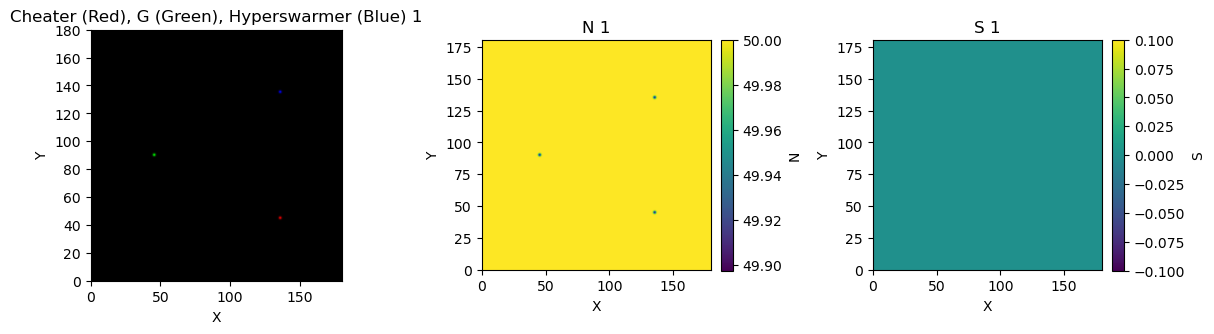

Step 0: Time = 0.0000


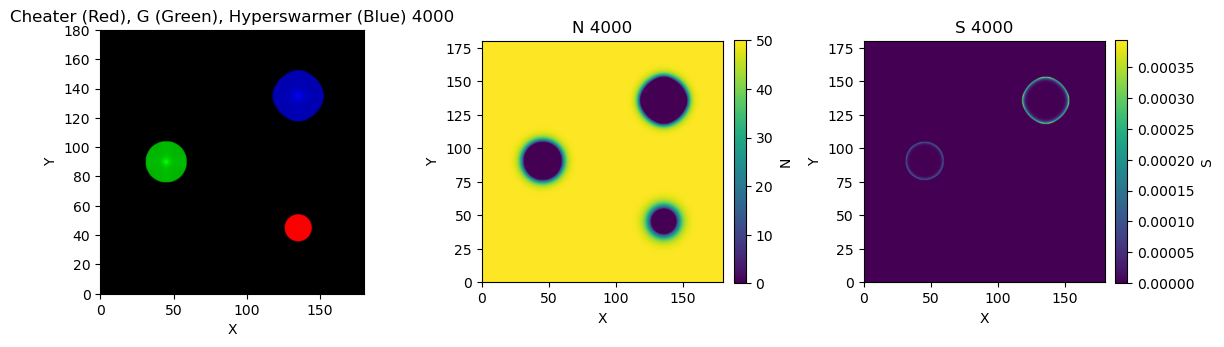

Step 3999: Time = 3.9990


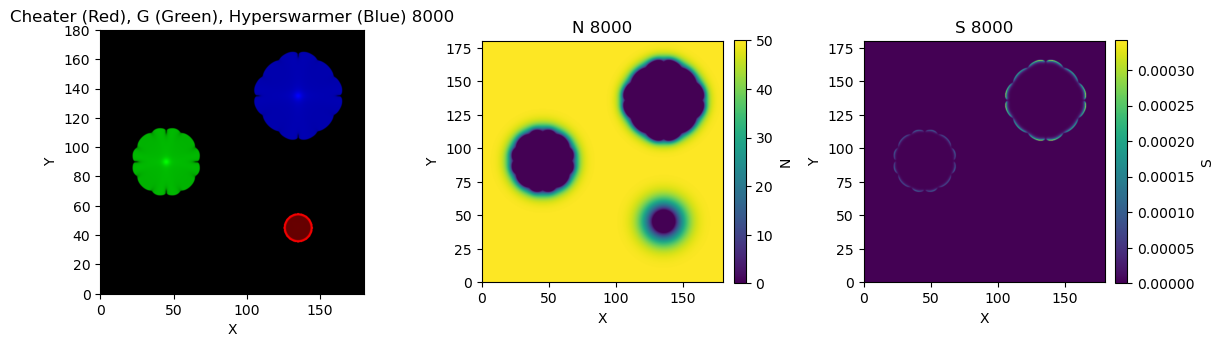

Step 7999: Time = 7.9990


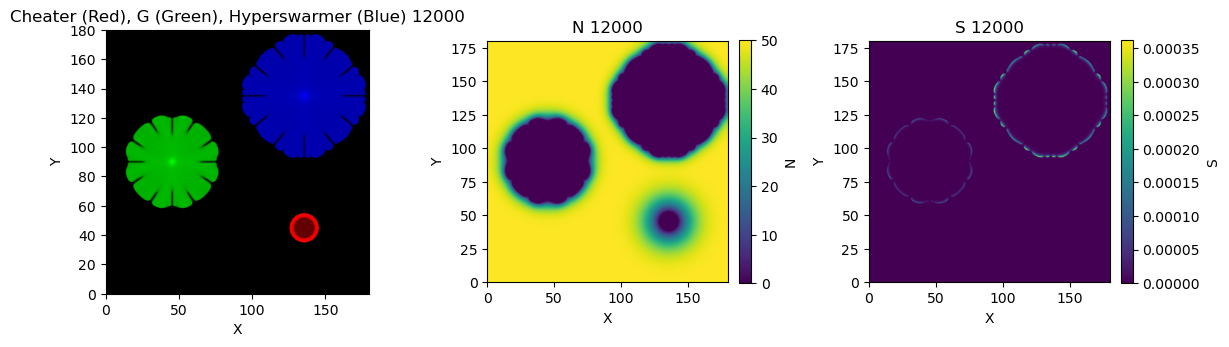

Step 11999: Time = 11.9990


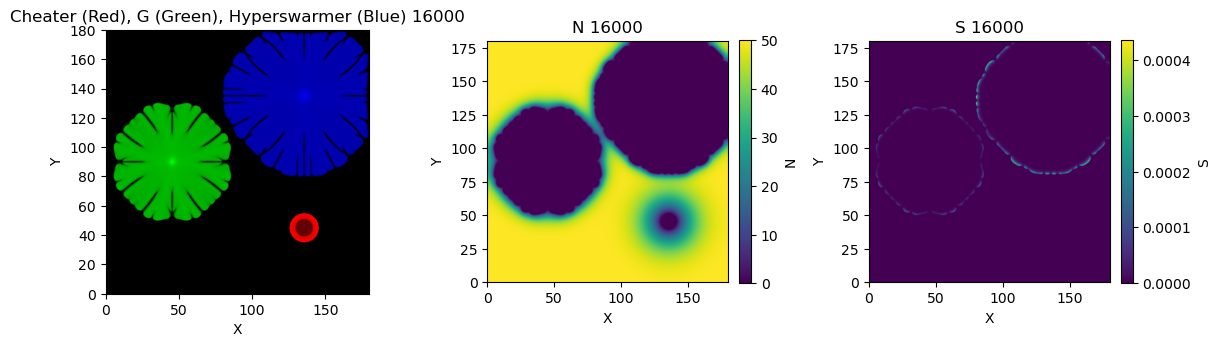

Step 15999: Time = 15.9990


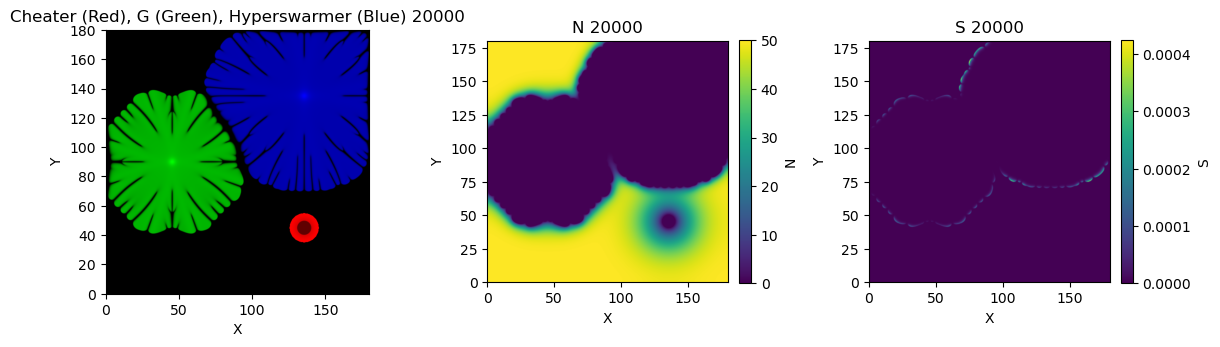

Step 19999: Time = 19.9990
Simulation completed.
Simulation took 35.83 seconds


In [17]:


#parameters to generate branching
# L = 80
# base parameters (from Nan)
# with modifications aS = 5. 

def run_simulation_fdm():
    """
    Runs the PDE simulation for nutrient concentration (N), proliferating cells (P),
    specialized cells (G), and surfactant (S), using finite difference methods.
    Injects noise into the effective diffusivity D_eff.
    Computes colony area by thresholding C > 0.01 and plots colony radius as a function of time.
    """
    '''
    # Define grid parameters
    nx, ny = 600, 600  # Number of grid points (matches MATLAB's nx=401)
    Lx, Ly = 180, 180  # Physical domain size, matching MATLAB's L=20
    dx = Lx / nx
    dy = Ly / ny

    # Define total simulation time and steps
    dt = 1e-3 
    nt = 20000*2  # Number of time steps
    frames = 5
    samples = 100

    # Define PDE parameters
    # Parameters = [DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, bS, KE, KC, Cmax, n, d, a, b, KP, delta, N0, C0]

    # The parameter values are chosen to reflect the scaled values.
    
    Parameters = [
        8,    #  DN = 1-20 (good results) 
        0.579,    # DS = 5.79
        2e3,    # kP * Cmax, kP=2.58e3
        22,    # bN * Cmax/KN; bN = 15
        24.24,    # aG= 24.24
        8.67,    # aP/aP; aP = 8.67 
        75.36,    # kG = 75.36
        16.98,    # kP = 16.98

        1,   # (fixed. scaling basis for concentrations)

        10,    # KT/KN; KT = 6.45

        1,    #  aS = 1.0 (fixed. basis for time)

        0.2,    #aS1 (cheater) seems to be roughly accurate for 0.1 and below (not swarming but slight trails),
                #Not stable below 0.7, forms diamond shape rather than circle

        2,   # aS2 = 2.0....(hyperswarmer )

        5,    #  bS = 170.52
        9,    # KE/KN; KE = 6.08
        6,    # KC/KN; KC = 4.55

        10,    #Cmax/Cmax; Cmax= 10  (fixed. scaling basis for cell density and surfactant)

        2,    # n_param
        2.205,    # d_param
        1.69,    # a_param
        1.84,    # b_param
        3.21,    # KP/KN; KP = 2.06
        50,    # N0/KN; N0 = 31.5
        0.2     # C0/Cmax; C0 = 1.59
    ]

    # Extract parameters
    DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, aS1, as2, bS, KE, KC, Cmax, n, d, a, b, KP, N0, C0 = Parameters

    print(Parameters)
    # Update pde_params tuple
    '''
    pde_params = (DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, aS1, as2, bS, KE, KC, Cmax, n, d, a, b, KP)
    # Define initial conditions
    R0 = 1.0    # Radius for initial cell concentration, matching MATLAB's exp(- (rr/1)^2 )

    Locs_wt = [(Lx/2+1, Ly/2+1)] #for if the same spot
    Locs_c = [(Lx/2, Ly/2)]
    Locs_hypsw = [(Lx/2-1, Ly/2-1)]
    N_initial, P_initial, G_initial, P_initial_c, G_initial_c, P_initial_hs, G_initial_hs, S_initial = initialize_fields(nx, ny, Lx, Ly, N0, C0, R0) #normal case
    #N_initial, P_initial, G_initial, P_initial_c, G_initial_c, P_initial_hs, G_initial_hs, S_initial = initialize_fields(nx, ny, Lx, Ly, N0, C0, R0, Locs_wt, Locs_c, Locs_hypsw) #test case
    pde_state = (N_initial, P_initial, G_initial, P_initial_c, G_initial_c, P_initial_hs, G_initial_hs, S_initial)

    # Define noise parameters
    epsilon = 0 # Noise amplitude; adjust as needed

    # Initialize PRNG key
    seed = 42  # Arbitrary seed for reproducibility
    key = jax.random.PRNGKey(seed)

    # Create directory to save outputs (optional)
    save_dir = 'simulation_outputs_fdm'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Simulation loop
    for step in range(nt):
        # Generate a new random key for this step
        key, subkey = jax.random.split(key)

        # Generate noise: Gaussian noise with mean 0 and standard deviation epsilon
        noise = epsilon * (jax.random.uniform(subkey, shape=(nx, ny)) * 2 - 1)

        # Update PDE state with noise injected into D_eff using FDM
        pde_state, _ = pde_update_fdm(
            pde_state,
            pde_params,
            dx,
            dy,
            dt,
            noise
        )

    
        # Extract updated N, P, G, G_C, P_HS, G_HS, S
        N, P, G, P_C, G_C, P_HS, G_HS, S = pde_state

        # Compute total cell density C = P + G
        C = P + G

        # Compute total cell density for cheater and hyperswarmer
        C_C= P_C + G_C
        C_HS= P_HS + G_HS


        # Optional: Visualization and data saving every 500 steps
        if (step == 0) or ((step+1) % (nt//frames) == 0):
            plt.figure(figsize=(12, 5))

            # Create composite RGB image for P and G
            composite_image = np.zeros((nx, ny, 3))
            
            # Right now the growers outnumber the producers by a order of magnitude
            # So currently we change the color scheme to highlight the cheaters and hyperswarmers. 

            composite_image[..., 1] = G  # Green channel for G
            composite_image[..., 0] = G_C # Red channel for cheater G_C 
            composite_image[..., 2] = G_HS # Blue channel for hyperswarmer G_HS

            # composite_image = composite_image / composite_image.max()  # Normalize to [0, 1]

            # now we normalize the image, so that the color intensity is normalized on the respective species cell densities
            composite_image[..., 0] = composite_image[..., 0] / (G_C.max() + 1e-8)
            composite_image[..., 1] = composite_image[..., 1] / (G.max() + 1e-8)
            composite_image[..., 2] = composite_image[..., 2] / (G_HS.max() + 1e-8)

            # Plot Composite Image of P and G
            plt.subplot(1, 3, 1)
            plt.imshow(composite_image, extent=(0, Lx, 0, Ly), origin='lower')
            plt.title(f'Cheater (Red), G (Green), Hyperswarmer (Blue) {step + 1}')
            plt.xlabel('X')
            plt.ylabel('Y')

            # Plot N (Nutrient Concentration)
            plt.subplot(1, 3, 2)
            im_n = plt.imshow(N, extent=(0, Lx, 0, Ly), origin='lower', cmap='viridis')
            cbar_n = plt.colorbar(im_n, fraction=0.046, pad=0.04)
            cbar_n.ax.set_ylabel('N')
            plt.title(f'N {step + 1}')
            plt.xlabel('X')
            plt.ylabel('Y')

            # Plot S (Surfactant Concentration)
            plt.subplot(1, 3, 3)
            im_s = plt.imshow(S, extent=(0, Lx, 0, Ly), origin='lower', cmap='viridis')
            cbar_s = plt.colorbar(im_s, fraction=0.046, pad=0.04)
            cbar_s.ax.set_ylabel('S')
            plt.title(f'S {step + 1}')
            plt.xlabel('X')
            plt.ylabel('Y')

            plt.tight_layout()
            plt.show()
          

            # Print progress and colony radius
            print(f"Step {step}: Time = {step*dt:.4f}")

    print("Simulation completed.")




start = time.time()
run_simulation_fdm()
end = time.time()
print(f"Simulation took {end - start:.2f} seconds")


In [13]:
'''

#parameters to generate branching
# L = 80
# base parameters (from Nan)
# with modifications aS = 5. 

def run_simulation_fdm():
    """
    Runs the PDE simulation for nutrient concentration (N), proliferating cells (P),
    specialized cells (G), and surfactant (S), using finite difference methods.
    Injects noise into the effective diffusivity D_eff.
    Computes colony area by thresholding C > 0.01 and plots colony radius as a function of time.
    """
    # Define grid parameters
    nx, ny = 600, 600  # Number of grid points (matches MATLAB's nx=401)
    Lx, Ly = 180, 180  # Physical domain size, matching MATLAB's L=20
    dx = Lx / nx
    dy = Ly / ny

    # Define total simulation time and steps
    dt = 1e-3  
    nt = 20000  # Number of time steps
    frames = 10
    samples = 100

    # Define PDE parameters
    # Parameters = [DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, bS, KE, KC, Cmax, n, d, a, b, KP, delta, N0, C0]

    # The parameter values are chosen to reflect the scaled values.
    
    Parameters = [
        8,    #  DN = 1-20 (good results) 
        0.579,    # DS = 5.79
        2e3,    # kP * Cmax, kP=2.58e3
        22,    # bN * Cmax/KN; bN = 15
        24.24,    # aG= 24.24
        8.67,    # aP/aP; aP = 8.67 
        75.36,    # kG = 75.36
        16.98,    # kP = 16.98

        1,   # (fixed. scaling basis for concentrations)

        10,    # KT/KN; KT = 6.45

        1,    #  aS = 1.0 (fixed. basis for time)

        0.1, 

        2,   # aS2 = 2.0....(hyperswarmer )

        5,    #  bS = 170.52
        9,    # KE/KN; KE = 6.08
        6,    # KC/KN; KC = 4.55

        10,    #Cmax/Cmax; Cmax= 10  (fixed. scaling basis for cell density and surfactant)

        2,    # n_param
        2.205,    # d_param
        1.69,    # a_param
        1.84,    # b_param
        3.21,    # KP/KN; KP = 2.06
        50,    # N0/KN; N0 = 31.5
        0.2     # C0/Cmax; C0 = 1.59
    ]

    # Extract parameters
    DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, aS1, as2, bS, KE, KC, Cmax, n, d, a, b, KP, N0, C0 = Parameters

    print(Parameters)
    # Update pde_params tuple
    pde_params = (DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, aS1, as2, bS, KE, KC, Cmax, n, d, a, b, KP)
    # Define initial conditions
    R0 = 1.0    # Radius for initial cell concentration, matching MATLAB's exp(- (rr/1)^2 )

    N_initial, P_initial, G_initial, P_initial_c, G_initial_c, P_initial_hs, G_initial_hs, S_initial = initialize_fields(nx, ny, Lx, Ly, N0, C0, R0)
    pde_state = (N_initial, P_initial, G_initial, P_initial_c, G_initial_c, P_initial_hs, G_initial_hs, S_initial)

    # Define noise parameters
    epsilon = 0.2 # Noise amplitude; adjust as needed

    # Initialize PRNG key
    seed = 42  # Arbitrary seed for reproducibility
    key = jax.random.PRNGKey(seed)

    # Create directory to save outputs (optional)
    save_dir = 'simulation_outputs_fdm'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Simulation loop
    for step in range(nt):
        # Generate a new random key for this step
        key, subkey = jax.random.split(key)

        # Generate noise: Gaussian noise with mean 0 and standard deviation epsilon
        noise = epsilon * (jax.random.uniform(subkey, shape=(nx, ny)) * 2 - 1)

        # Update PDE state with noise injected into D_eff using FDM
        pde_state, _ = pde_update_fdm(
            pde_state,
            pde_params,
            dx,
            dy,
            dt,
            noise
        )

    
        # Extract updated N, P, G, G_C, P_HS, G_HS, S
        N, P, G, P_C, G_C, P_HS, G_HS, S = pde_state

        # Compute total cell density C = P + G
        C = P + G

        # Compute total cell density for cheater and hyperswarmer
        C_C= G_C+P_C
        C_HS= P_HS + G_HS


        # Optional: Visualization and data saving every 500 steps
        if (step == 0) or ((step+1) % (nt//frames) == 0):
            plt.figure(figsize=(12, 5))

            # Create composite RGB image for P and G
            composite_image = np.zeros((nx, ny, 3))
            
            # Right now the growers outnumber the producers by a order of magnitude
            # So currently we change the color scheme to highlight the cheaters and hyperswarmers. 

            composite_image[..., 1] = G  # Green channel for G
            composite_image[..., 0] = G_C # Red channel for cheater G_C 
            composite_image[..., 2] = G_HS # Blue channel for hyperswarmer G_HS

            # composite_image = composite_image / composite_image.max()  # Normalize to [0, 1]

            # now we normalize the image, so that the color intensity is normalized on the respective species cell densities
            composite_image[..., 0] = composite_image[..., 0] / (G_C.max() + 1e-8)
            composite_image[..., 1] = composite_image[..., 1] / (G.max() + 1e-8)
            composite_image[..., 2] = composite_image[..., 2] / (G_HS.max() + 1e-8)

            # Plot Composite Image of P and G
            plt.subplot(1, 3, 1)
            plt.imshow(composite_image, extent=(0, Lx, 0, Ly), origin='lower')
            plt.title(f'Cheater (Red), G (Green), Hyperswarmer (Blue) {step + 1}')
            plt.xlabel('X')
            plt.ylabel('Y')

            # Plot N (Nutrient Concentration)
            plt.subplot(1, 3, 2)
            im_n = plt.imshow(N, extent=(0, Lx, 0, Ly), origin='lower', cmap='viridis')
            cbar_n = plt.colorbar(im_n, fraction=0.046, pad=0.04)
            cbar_n.ax.set_ylabel('N')
            plt.title(f'N {step + 1}')
            plt.xlabel('X')
            plt.ylabel('Y')

            # Plot S (Surfactant Concentration)
            plt.subplot(1, 3, 3)
            im_s = plt.imshow(S, extent=(0, Lx, 0, Ly), origin='lower', cmap='viridis')
            cbar_s = plt.colorbar(im_s, fraction=0.046, pad=0.04)
            cbar_s.ax.set_ylabel('S')
            plt.title(f'S {step + 1}')
            plt.xlabel('X')
            plt.ylabel('Y')

            plt.tight_layout()
            plt.show()
          

            # Print progress and colony radius
            print(f"Step {step}: Time = {step*dt:.4f}")

    print("Simulation completed.")




start = time.time()
run_simulation_fdm()
end = time.time()
print(f"Simulation took {end - start:.2f} seconds")
'''

'\n\n#parameters to generate branching\n# L = 80\n# base parameters (from Nan)\n# with modifications aS = 5. \n\ndef run_simulation_fdm():\n    """\n    Runs the PDE simulation for nutrient concentration (N), proliferating cells (P),\n    specialized cells (G), and surfactant (S), using finite difference methods.\n    Injects noise into the effective diffusivity D_eff.\n    Computes colony area by thresholding C > 0.01 and plots colony radius as a function of time.\n    """\n    # Define grid parameters\n    nx, ny = 600, 600  # Number of grid points (matches MATLAB\'s nx=401)\n    Lx, Ly = 180, 180  # Physical domain size, matching MATLAB\'s L=20\n    dx = Lx / nx\n    dy = Ly / ny\n\n    # Define total simulation time and steps\n    dt = 1e-3  \n    nt = 20000  # Number of time steps\n    frames = 10\n    samples = 100\n\n    # Define PDE parameters\n    # Parameters = [DN, DS, kD, bN, aG, aP, kG, kP, KN, KT, aS, bS, KE, KC, Cmax, n, d, a, b, KP, delta, N0, C0]\n\n    # The parameter